# 单元4作业
    刘易昊 524021910055

首先进行一些基础设定：
- 加载常用的头文件
- 设置中文显示格式，避免乱码


In [34]:
#加载头文件
import numpy as np
import pandas as pd
import scipy.stats as stats
import statistics as sta
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
#中文显示设置
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"] 

## 问题一 （单因素ANOVA， 2分）
在高血压治疗中，降压药物的效果是一个关键研究领域。某项研究希望评估不同剂量的某种降压药物对患者收缩压的降低幅度是否存在显著差异。研究设计如下：
- 研究对象：90 名高血压患者，随机分配至 3 组（每组 30 人）。
- 处理方式：
  - 对照组（未服用药物）
  - 低剂量组（服用 10mg）
  - 高剂量组（服用 20mg）
- 主要测量指标：服药 4 周后的收缩压降低值（mmHg）。

本研究旨在使用单因素方差分析（One-way ANOVA）评估三组之间的均值差异是否具有统计学意义。

### 任务 1：数据导入与可视化
1. 下载数据文件  one_way_anova_biomed.csv。


In [35]:
data1=pd.read_csv('one_way_anova_biomed.csv')
data1.head()

,Group,dSBP
0,Ctr,2.745071
1,Ctr,1.792604
2,Ctr,2.971533
3,Ctr,4.284545
4,Ctr,1.648770


2. 使用 Python 和手工方法分别计算三组的描述性统计量（均值、标准差、中位数）。


In [36]:
desc_data1 = data1.groupby("Group")["dSBP"].agg([
    ("均值", "mean"),
    ("标准差", "std"),
    ("中位数", "median"),
])

display(desc_data1)

,均值,标准差,中位数
Group,,,
Ctr,1.717780,1.350010,1.648782
HighDose,8.025770,1.983966,8.051221
LowDose,4.781908,1.675984,4.883769


使用 groupby 函数和 agg 函数对数据进行分组并计算相对应的统计量，计算结果如上表所示。

若需要手工计算，则利用公式：
- 均值 $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$
- 标准差 $s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$
- 中位数，即把数据按从小打大排列的百分之五十分位数 $ x_{0.5} $

进手工计算后，得到结果与上表格一致。

3. 使用箱线图（boxplot）和散点图（stripplot）可视化三组数据的分布情况。

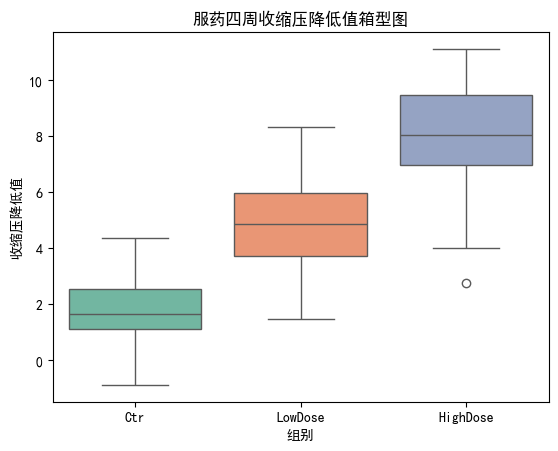

In [37]:
sns.boxplot(
    data=data1,
    x='Group',
    y='dSBP',
    hue='Group',
    palette='Set2'
)
#添加中文标注
plt.title("服药四周收缩压降低值箱型图")
plt.xlabel("组别")
plt.ylabel("收缩压降低值")
plt.show()

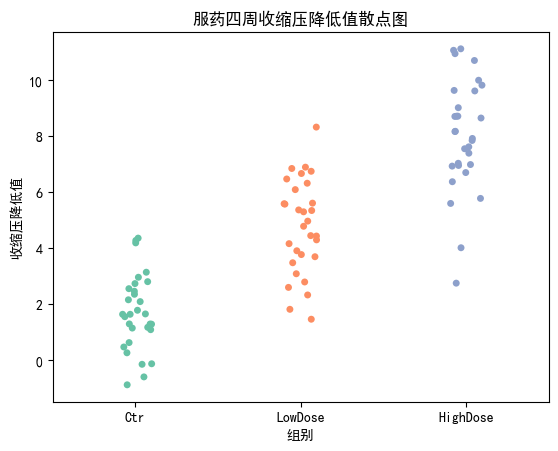

In [38]:
sns.stripplot(
    data=data1,
    x='Group',
    y='dSBP',
    hue='Group',
    palette='Set2'    
)
#添加中文标注
plt.title("服药四周收缩压降低值散点图")
plt.xlabel("组别")
plt.ylabel("收缩压降低值")
plt.show()

### 任务 2：单因素方差分析
1.  手工计算 ANOVA  
   - 计算 SST（总平方和）、SSB（组间平方和）、SSW（组内平方和）。
   - 计算 F 值，并查找 F 分布表确定显著性水平。

计算过程如下：

$ SST=\sum_{i=1}^{k}\sum_{j=1}{n_i}(x_{ij}-\bar{x}_{\cdot\cdot})^2 = 845.482088 $

$ SSB=\sum_{i=1}^{k}n_i(\bar{x}_{i\cdot}-\bar{x}_{\cdot\cdot})^2 = 597.022568 $

$ SSW=\sum_{i=1}^{k}\sum_{j=1}{n_i}(x_{ij}-\bar{x}_{i\cdot})^2 = 248.459520 $

以上三个统计的的自由度分别为：$ df_t=N-1=89$， $df_b=k-1=2$， $df_w=N-k=87 $

所以F统计量为 $ F \sim F(2,87)$，$ F_{obs}= \frac{SSB/df_b}{SSW/df_w} = 104.526008 $ 

查表可知：$p=P(F>F_{obs})=2.22 \times 10^{-16} \approx 0$

2. Python 实现 ANOVA
   - 使用 pingouin.anova进行单因素方差分析。

In [39]:
aov=data1.anova(
    dv='dSBP', 
    between="Group",
    detailed=True
)
print(aov.round(6))

   Source          SS  DF          MS           F  p_unc       np2
0   Group  597.022568   2  298.511284  104.526008    0.0  0.706133
1  Within  248.459520  87    2.855857         NaN    NaN       NaN


任务 3：事后检验（Post-hoc Tests）
如果 ANOVA 结果显示组间差异显著，需进一步进行事后检验：
1. 使用 pingouin 包中的Tukey HSD 检验进行多重比较。



根据手工计算和Python计算，得到的 $p \approx 0 < \alpha=0.05 $，显示组间差异显著，需要进一步事后检验。

In [40]:
hsd=data1.pairwise_tukey(
    dv='dSBP', 
    between='Group',
)
print(hsd.round(4))

          A         B  mean_A  mean_B    diff      se        T  p_tukey  \
0       Ctr  HighDose  1.7178  8.0258 -6.3080  0.4363 -14.4567      0.0   
1       Ctr   LowDose  1.7178  4.7819 -3.0641  0.4363  -7.0224      0.0   
2  HighDose   LowDose  8.0258  4.7819  3.2439  0.4363   7.4343      0.0   

   hedges  
0 -3.6692  
1 -1.9874  
2  1.7434  


2. 用pingouin包中pairwise_tests函数，用Bonferroni 校正方法

In [41]:
bon=data1.pairwise_tests(
    dv='dSBP', 
    between='Group', 
    padjust='bonferroni', 
)

print(bon.round(4))

  Contrast         A         B  Paired  Parametric        T   dof alternative  \
0    Group       Ctr  HighDose   False        True -14.3976  58.0   two-sided   
1    Group       Ctr   LowDose   False        True  -7.7985  58.0   two-sided   
2    Group  HighDose   LowDose   False        True   6.8412  58.0   two-sided   

   p_unc  p_corr    p_adjust       BF10  hedges  
0    0.0     0.0  bonferroni  3.155e+17 -3.6692  
1    0.0     0.0  bonferroni  5.189e+07 -1.9874  
2    0.0     0.0  bonferroni  1.621e+06  1.7434  


任务 4：结果汇报（APA格式）： 请按照APA 格式撰写统计分析结果，包括：
- 描述性统计结果
- 方差分析 F 检验结果 (包括效应量值）
- 事后检验结果
- 解释统计结果的生物医学意义

结果汇报：

在本研究中，采用单因素方差分析考察不同剂量的某种降压药物对患者收缩压的降低幅度的影响。结果表明，测试类型的主效应显著，$F(2, 87)=104.53$，$p < .001$， $\eta^2=0.706$（大效应），且事后检验 $p$ 值均为0，表明不同剂量降压药物对收缩压的降低幅度是存在较大的差异的。

## 问题二：（两因素方差分析， 2分）
一名神经科学研究人员，正在研究不同类型的认知训练(记忆训练、注意力训练或对照组)和年龄组(青年组18-35岁、中年组36-55岁、老年组56-75岁)对认知表现的影响。您招募了90名志愿者，每个年龄组和训练类型组合有10名参与者。所有参与者完成6周的训练后，进行认知能力测试，得分范围为0-100分。（数据文件： cognitive_training.csv)

### 任务1：对数据进行可视化分析：

1. 创建交互图显示不同训练类型和年龄组的认知得分



In [42]:
data2=pd.read_csv('cognitive_training.csv')
data2.head()

,participant_id,age_group,training_type,cognitive_score,education_years,gender
0,1,young,memory,90.5,17,F
1,2,young,memory,87.3,19,M
2,3,young,memory,86.8,17,M
3,4,young,memory,86.8,19,F
4,5,young,memory,90.0,19,F


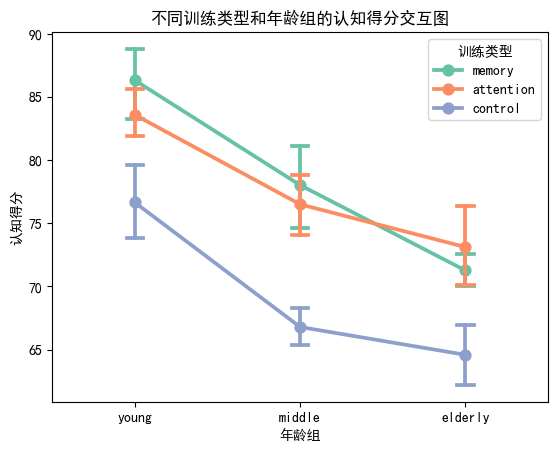

In [43]:
sns.pointplot(
    x='age_group',
    y='cognitive_score', 
    hue='training_type', 
    palette='Set2',
    data=data2, 
    capsize=0.1
)
#添加标注
plt.title("不同训练类型和年龄组的认知得分交互图")
plt.xlabel("年龄组")
plt.ylabel("认知得分")
plt.legend(title="训练类型")
plt.show()


2. 绘制各组的均值条形图及误差线(95%置信区间)

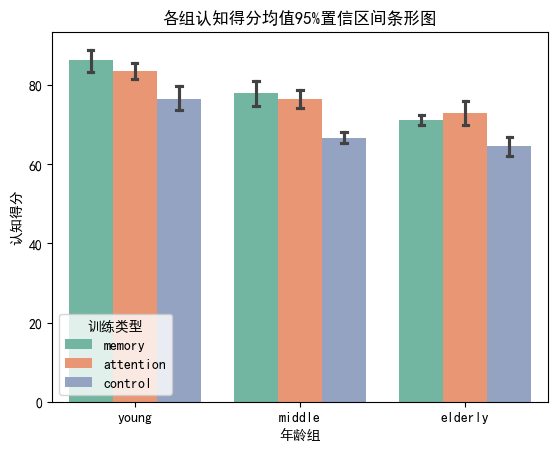

In [44]:
sns.barplot(
    x='age_group', 
    y='cognitive_score', 
    hue='training_type', 
    palette='Set2',
    data=data2,
    errorbar=('ci', 95),
    capsize=0.1 
)
#添加标注
plt.title('各组认知得分均值95%置信区间条形图')
plt.xlabel('年龄组')
plt.ylabel('认知得分')
plt.legend(title='训练类型')
plt.show()

### 任务2：进行描述性统计分析：

- 计算每个组合的样本量、均值、标准差


In [45]:
desc_data2=data2.groupby(["age_group", "training_type"])["cognitive_score"].agg([
    ("样本量", "count"),
    ("均值", "mean"),
    ("标准差", "std")
])

display(desc_data2.round(6))

样本量     均值       标准差
age_group training_type                      
elderly   attention       10  73.11  5.486438
          control         10  64.59  4.045148
          memory          10  71.26  2.226208
middle    attention       10  76.49  3.885143
          control         10  66.79  2.529141
          memory          10  78.01  5.410371
young     attention       10  83.57  3.263961
          control         10  76.64  5.049576
          memory          10  86.30  4.895576

- 计算主效应的边际均值及其95%置信区间

首先我们先定义一个计算置信区间的函数

In [46]:
def mean_ci_t(data,ci=0.95):
    n=len(data)
    std=np.std(data,ddof=1)
    m=np.mean(data)
    sem=std/np.sqrt(n)
    moe=stats.t.isf((1-ci)/2,n-1)*sem
    return m,m-moe,m+moe

然后分别提取两个主效应共六组数据，并计算置信区间

In [47]:
young = data2[data2["age_group"] == "young"]["cognitive_score"]
middle = data2[data2["age_group"] == "middle"]["cognitive_score"]
elderly = data2[data2["age_group"] == "elderly"]["cognitive_score"]
memory = data2[data2["training_type"] == "memory"]["cognitive_score"]
attention = data2[data2["training_type"] == "attention"]["cognitive_score"]
control = data2[data2["training_type"] == "control"]["cognitive_score"]

m_young, l_young, h_young = mean_ci_t(young, 0.95)
print(f"young的边际均值是: {m_young:.2f}，young的95%置信区间是: [{l_young:.2f}, {h_young:.2f}]")

m_middle, l_middle, h_middle = mean_ci_t(middle, 0.95)
print(f"middle的边际均值是: {m_middle:.2f}，middle的95%置信区间是: [{l_middle:.2f}, {h_middle:.2f}]")

m_elderly, l_elderly, h_elderly = mean_ci_t(elderly, 0.95)
print(f"elderly的边际均值是: {m_elderly:.2f}，elderly的95%置信区间是: [{l_elderly:.2f}, {h_elderly:.2f}]")

# 训练类型组
m_memory, l_memory, h_memory = mean_ci_t(memory, 0.95)
print(f"memory的边际均值是: {m_memory:.2f}，memory的95%置信区间是: [{l_memory:.2f}, {h_memory:.2f}]")

m_attention, l_attention, h_attention = mean_ci_t(attention, 0.95)
print(f"attention的边际均值是: {m_attention:.2f}，attention的95%置信区间是: [{l_attention:.2f}, {h_attention:.2f}]")

m_control, l_control, h_control = mean_ci_t(control, 0.95)
print(f"control的边际均值是: {m_control:.2f}，control的95%置信区间是: [{l_control:.2f}, {h_control:.2f}]")

young的边际均值是: 82.17，young的95%置信区间是: [79.94, 84.40]
middle的边际均值是: 73.76，middle的95%置信区间是: [71.36, 76.16]
elderly的边际均值是: 69.65，elderly的95%置信区间是: [67.61, 71.69]
memory的边际均值是: 78.52，memory的95%置信区间是: [75.70, 81.35]
attention的边际均值是: 77.72，attention的95%置信区间是: [75.45, 79.99]
control的边际均值是: 69.34，control的95%置信区间是: [66.88, 71.80]


### 任务3：评估数据是否满足两因素ANOVA的假设：

- 检验各组数据的正态性



In [48]:
data2['cell'] = data2["age_group"].astype(str) + '_' + data2["training_type"].astype(str)
normality_result = pg.normality(data=data2,dv="cognitive_score",group='cell')

print(normality_result)

                          W      pval  normal
cell                                         
young_memory       0.894291  0.189433    True
young_attention    0.918068  0.341120    True
young_control      0.925290  0.403190    True
middle_memory      0.889598  0.167819    True
middle_attention   0.957877  0.761425    True
middle_control     0.953790  0.713405    True
elderly_memory     0.945404  0.614545    True
elderly_attention  0.975629  0.937576    True
elderly_control    0.951113  0.681682    True


可以看到，所有数据均符合正态性。

- 检验方差齐性（不同因素水平上的方差是否相似）



In [49]:
pg.homoscedasticity(data=data2, dv="cognitive_score", group="cell", method="levene")

,W,pval,equal_var
levene,1.588227,0.141229,True


可以看到方差齐性检验也为真。

- 检查异常值

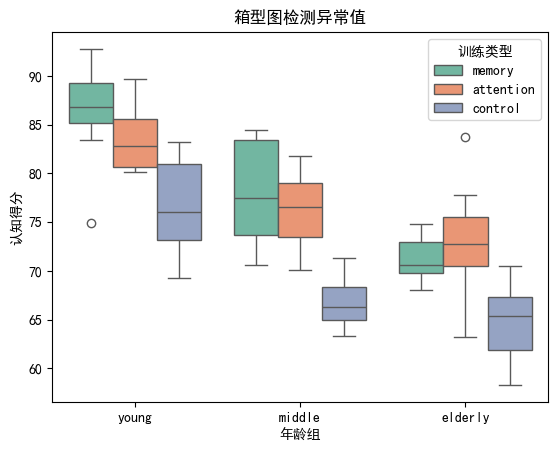

In [50]:
sns.boxplot(
    x='age_group', 
    y='cognitive_score', 
    hue='training_type', 
    palette='Set2',
    data=data2
)
plt.title('箱型图检测异常值')
plt.xlabel("年龄组")
plt.ylabel("认知得分")
plt.legend(title="训练类型")
plt.show()

在箱型图中，$ [Q_1-1.5IQR, Q_3+1.5IQR] $ 区间之外的值被标注为异常值。

如上图，可以看到young_memory和elderly_attention组分别有一个异常值。

### 任务4：进行两因素ANOVA分析：

- 分析训练类型主效应、年龄组主效应以及它们的交互作用

- 计算各效应的效应量(η²)

- 如有显著交互作用，进行简单主效应分析

- 进行适当的事后多重比较(Tukey HSD)(如果主效应不显著，不需要做）

In [51]:
aov = pg.anova(
    dv="cognitive_score", 
    between=["age_group", "training_type"], 
    data=data2, 
    detailed=True
)
print(aov.round(4))

                      Source         SS  DF         MS        F   p_unc  \
0                  age_group  2442.3109   2  1221.1554  67.7159  0.0000   
1              training_type  1552.5389   2   776.2694  43.0460  0.0000   
2  age_group * training_type    86.0744   4    21.5186   1.1933  0.3201   
3                   Residual  1460.7140  81    18.0335      NaN     NaN   

      np2  
0  0.6257  
1  0.5152  
2  0.0556  
3     NaN  


- 年龄主效应F(2,81)= 7.7159，p<0.001，达到显著水平，说明不同年龄组的认知得分存在统计学差异。训练类型主效应F(2,81)=43.0460，p<0.001，达到显著水平，说明不同训练类型的认知得分存在统计学差异。相互作用F(4,81)=1.1933，p=0.3201>0.05，不显著，说明年龄对认知得分的影响不随训练类型改变，训练类型的效果不随年龄改变，二者无交互叠加效应。
- 从上表可以看到年龄组的偏$\eta^2$=0.6257，训练类型组的偏$\eta^2$=0.5152，交互作用的偏$\eta^2$=0.0556；若计算普通的$\eta^2$则三个数据分别为：0.4407、0.2802和0.0155。
- 可以看到无显著的交互作用，故不进行主效应分析。
- 主效应均显著，进行事后多重比较：

In [52]:
tukey_age = pg.pairwise_tukey(
    data=data2,
    dv="cognitive_score",
    between="age_group"
)
print("年龄组 Tukey HSD 两两比较结果")
print(tukey_age.round(4))

tukey_train = pg.pairwise_tukey(
    data=data2,
    dv="cognitive_score",
    between="training_type"
)
print("训练类型 Tukey HSD 两两比较结果")
print(tukey_train.round(4))


年龄组 Tukey HSD 两两比较结果
         A       B   mean_A   mean_B     diff      se       T  p_tukey  hedges
0  elderly  middle  69.6533  73.7633  -4.1100  1.5411 -2.6669   0.0245 -0.6803
1  elderly   young  69.6533  82.1700 -12.5167  1.5411 -8.1219   0.0000 -2.1576
2   middle   young  73.7633  82.1700  -8.4067  1.5411 -5.4550   0.0000 -1.3367
训练类型 Tukey HSD 两两比较结果
           A        B   mean_A   mean_B    diff      se       T  p_tukey  \
0  attention  control  77.7233  69.3400  8.3833  1.7484  4.7950   0.0000   
1  attention   memory  77.7233  78.5233 -0.8000  1.7484 -0.4576   0.8912   
2    control   memory  69.3400  78.5233 -9.1833  1.7484 -5.2525   0.0000   

   hedges  
0  1.3054  
1 -0.1151  
2 -1.2782  


可以看到，年龄组两两比较均为显著；而训练类型组两两比较仅memory和attention之间不显著。

### 任务5：按APA格式报告结果，包括：

- 两个主效应和交互作用的F统计量、自由度、p值

- 各效应的效应量

- 多重比较结果表格 (如果主效应不显著，不需要做）

- 结合前面的数据评估，解释结果的理论和实践意义

结果汇报：
- 年龄组主效应显著，F(2, 81) = 67.72，p < .001，偏$\eta^2$= 0.626（大效应）。
- 训练类型主效应显著，F(2, 81) = 43.05，p < .001，偏$\eta^2$= 0.515（大效应）。
- 年龄组 × 训练类型交互作用不显著，F(4, 81) = 1.19，p = .320，偏$\eta^2$= 0.056（小效应）。

多重比较结果表格上所示。

- 理论意义：
    - 可以看到年龄的主效应显著病情效应量也是最大的，证实了认知功能随年龄增长衰减
    - 训练类型主效应同样显著，说明记忆训练和注意训练都能提升认知能力
    - 两种效应交互作用不显著，说明两种训练的效果不受年龄影响

- 实践意义：
    - 在选择认知训练的种类时，记忆训练和注意训练的效果无显著差异，且效果都显著
    - 记认知训练的效果对各年龄段都适用
